# Actividad 1
### Implementación de conceptos básicos de una regresión lineal
#### Autor: Dr. Hugo García Tecocoatzi

In [4]:
# Importa librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías importadas correctamente")
print(f"NumPy versión: {np.__version__}")

✅ Librerías importadas correctamente
NumPy versión: 2.1.3


In [5]:
# Generar datos sintéticos con relación lineal conocida
# y = 2x + 3 + ε, donde ε ~ N(0, 1.5)

np.random.seed(42)  # Fijar semilla para reproducibilidad

# Parámetros del modelo
n = 100  # Número de observaciones
X = np.random.rand(n, 1) * 10  # X entre 0 y 10
ruido = np.random.randn(n, 1) * 1.5  # Ruido con desviación 1.5
y = 2 * X + 3 + ruido  # y = 2x + 3 + ruido

print(f"✅ Datos generados")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nPrimeros 5 valores:")
print(f"X: {X[:5].flatten()}")
print(f"y: {y[:5].flatten()}")

✅ Datos generados
Dimensiones de X: (100, 1)
Dimensiones de y: (100, 1)

Primeros 5 valores:
X: [3.74540119 9.50714306 7.31993942 5.98658484 1.5601864 ]
y: [10.62137298 21.5657751  17.77752    11.99181631  5.79086498]


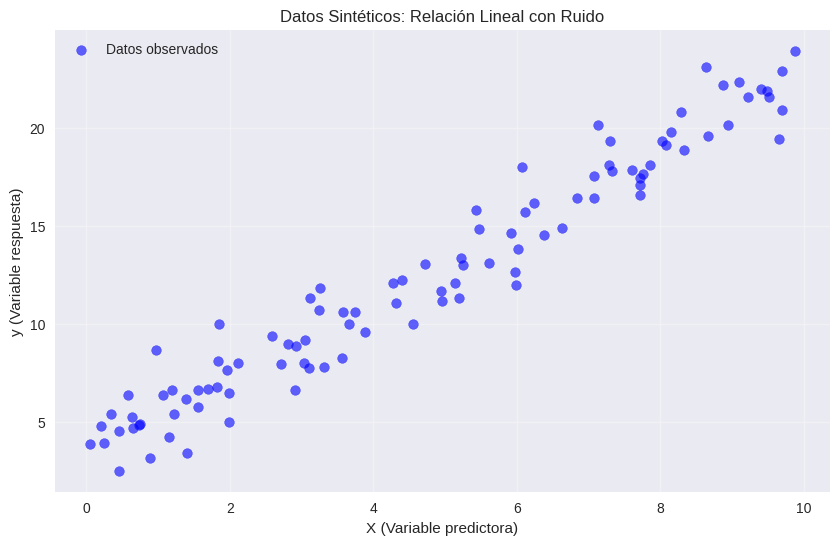

=== Estadísticas Descriptivas ===
Media de X: 4.702
Media de y: 12.402
Desviación estándar de X: 2.960
Desviación estándar de y: 5.872
Correlación entre X e y: 0.9733


In [6]:
#  Visualización exploratoria de los datos

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.6, color='blue', label='Datos observados')
plt.xlabel('X (Variable predictora)')
plt.ylabel('y (Variable respuesta)')
plt.title('Datos Sintéticos: Relación Lineal con Ruido')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Estadísticas descriptivas
print("=== Estadísticas Descriptivas ===")
print(f"Media de X: {np.mean(X):.3f}")
print(f"Media de y: {np.mean(y):.3f}")
print(f"Desviación estándar de X: {np.std(X):.3f}")
print(f"Desviación estándar de y: {np.std(y):.3f}")
print(f"Correlación entre X e y: {np.corrcoef(X.flatten(), y.flatten())[0,1]:.4f}")

In [7]:
# Estimación de parámetros usando MCO

# Calcular medias
X_mean = np.mean(X)
y_mean = np.mean(y)

# Calcular sumatorias
Sxx = np.sum((X - X_mean)**2)
Sxy = np.sum((X - X_mean) * (y - y_mean))

# Estimar coeficientes 
beta_1 = Sxy / Sxx
beta_0 = y_mean - beta_1 * X_mean

# Convertir a escalares si son arrays
if hasattr(beta_0, "__len__"):
    beta_0 = beta_0[0]
if hasattr(beta_1, "__len__"):
    beta_1 = beta_1[0]

print("=== Coeficientes Estimados ===")
print(f"β₀ (intersección) = {beta_0:.4f}")
print(f"β₁ (pendiente) = {beta_1:.4f}")
print(f"\n=== Valores Reales ===")
print(f"β₀ real = 3.0000")
print(f"β₁ real = 2.0000")
print(f"\n=== Errores de Estimación ===")
print(f"Error en β₀: {abs(beta_0 - 3):.4f}")
print(f"Error en β₁: {abs(beta_1 - 2):.4f}")


=== Coeficientes Estimados ===
β₀ (intersección) = 3.3226
β₁ (pendiente) = 1.9310

=== Valores Reales ===
β₀ real = 3.0000
β₁ real = 2.0000

=== Errores de Estimación ===
Error en β₀: 0.3226
Error en β₁: 0.0690


In [8]:
#Calcular predicciones y analizar residuos

# Predicciones (usando los escalares)
y_pred = beta_0 + beta_1 * X

# Residuos
residuos = y - y_pred

# Mostrar primeros 10 valores
print("=== Primeros 10 valores ===")
print("   y_real   y_pred   residuo")
print("-" * 30)
for i in range(10):
    print(f"{i+1:2d}  {y[i,0]:6.2f}   {y_pred[i,0]:6.2f}   {residuos[i,0]:7.3f}")

# Estadísticas de residuos
print("\n=== Estadísticas de Residuos ===")
print(f"Media de residuos: {np.mean(residuos):.6f} (debe ser ~0)")
print(f"Varianza de residuos: {np.var(residuos):.6f}")
print(f"Desviación estándar de residuos: {np.std(residuos):.4f}")
print(f"Suma de residuos: {np.sum(residuos):.6f} (debe ser ~0)")

=== Primeros 10 valores ===
   y_real   y_pred   residuo
------------------------------
 1   10.62    10.56     0.066
 2   21.57    21.68    -0.115
 3   17.78    17.46     0.320
 4   11.99    14.88    -2.891
 5    5.79     6.34    -0.545
 6    6.66     6.33     0.321
 7    6.38     4.44     1.934
 8   19.55    20.05    -0.503
 9   13.81    14.93    -1.121
10   16.41    17.00    -0.587

=== Estadísticas de Residuos ===
Media de residuos: -0.000000 (debe ser ~0)
Varianza de residuos: 1.814815
Desviación estándar de residuos: 1.3472
Suma de residuos: -0.000000 (debe ser ~0)


In [ ]:
# Cálculo detallado de la varianza del error

# Suma de cuadrados
SST = np.sum((y - np.mean(y))**2)  # Total
SSR = np.sum((y_pred - np.mean(y))**2)  # Explicada
SSE = np.sum((y - y_pred)**2)  # Residual

# Extraer valores escalares si son arrays
SST = SST[0] if hasattr(SST, "__len__") else SST
SSR = SSR[0] if hasattr(SSR, "__len__") else SSR
SSE = SSE[0] if hasattr(SSE, "__len__") else SSE

# Grados de libertad
n = len(y)
p = 1  # Número de variables predictoras
df_error = n - p - 1  # Grados de libertad del error

# Varianza del error (estimador insesgado)
sigma2_estimado = SSE / df_error
sigma_estimado = np.sqrt(sigma2_estimado)

# Varianza del error (estimador sesgado - solo para comparar)
sigma2_sesgado = SSE / n

print("=== Suma de Cuadrados ===")
print(f"SST (Total): {SST:.4f}")
print(f"SSR (Explicada): {SSR:.4f}")
print(f"SSE (Residual): {SSE:.4f}")
print(f"Verificación: SSR + SSE = {SSR + SSE:.4f} ≈ SST = {SST:.4f}")

print(f"\n=== Grados de Libertad ===")
print(f"n (observaciones): {n}")
print(f"p (predictores): {p}")
print(f"df_error (n-p-1): {df_error}")

print(f"\n=== Varianza del Error ===")
print(f"σ² estimado (insesgado) = SSE/(n-p-1) = {sigma2_estimado:.6f}")
print(f"σ² sesgado = SSE/n = {sigma2_sesgado:.6f}")
print(f"σ estimado = √σ² = {sigma_estimado:.6f}")

print(f"\n=== Comparación con valor real ===")
print(f"σ² real = {1.5**2:.4f} (ruido con desviación 1.5)")
print(f"σ² estimado = {sigma2_estimado:.4f}")
print(f"Diferencia: {abs(sigma2_estimado - 1.5**2):.4f}")

=== Suma de Cuadrados ===
SST (Total): 3448.5487
SSR (Explicada): 3267.0672
SSE (Residual): 181.4815
Verificación: SSR + SSE = 3448.5487 ≈ SST = 3448.5487

=== Grados de Libertad ===
n (observaciones): 100
p (predictores): 1
df_error (n-p-1): 98

=== Varianza del Error ===
σ² estimado (insesgado) = SSE/(n-p-1) = 1.851852
σ² sesgado = SSE/n = 1.814815
σ estimado = √σ² = 1.360828

=== Comparación con valor real ===
σ² real = 2.2500 (ruido con desviación 1.5)
σ² estimado = 1.8519
Diferencia: 0.3981


In [10]:
# Cálculo de la varianza de los coeficientes estimados

# Extraer Sxx como escalar
Sxx_val = Sxx[0] if hasattr(Sxx, "__len__") else Sxx
X_mean_val = X_mean[0] if hasattr(X_mean, "__len__") else X_mean

# Varianzas de los coeficientes
var_beta_1 = sigma2_estimado / Sxx_val
var_beta_0 = sigma2_estimado * (1/n + X_mean_val**2 / Sxx_val)

# Errores estándar
SE_beta_1 = np.sqrt(var_beta_1)
SE_beta_0 = np.sqrt(var_beta_0)

print("=== Varianza de los Coeficientes ===")
print(f"Var(β₀) = {var_beta_0:.6f}")
print(f"Var(β₁) = {var_beta_1:.6f}")

print(f"\n=== Errores Estándar ===")
print(f"SE(β₀) = {SE_beta_0:.6f}")
print(f"SE(β₁) = {SE_beta_1:.6f}")

print(f"\n=== Coeficientes con Error Estándar ===")
print(f"β₀ = {beta_0:.4f} ± {SE_beta_0:.4f}")
print(f"β₁ = {beta_1:.4f} ± {SE_beta_1:.4f}")

=== Varianza de los Coeficientes ===
Var(β₀) = 0.065244
Var(β₁) = 0.002114

=== Errores Estándar ===
SE(β₀) = 0.255430
SE(β₁) = 0.045974

=== Coeficientes con Error Estándar ===
β₀ = 3.3226 ± 0.2554
β₁ = 1.9310 ± 0.0460


In [11]:
# Cálculo de métricas de calidad del modelo

# R²
R2 = SSR / SST

# MSE y RMSE
MSE = np.mean((y - y_pred)**2)
MSE = MSE[0] if hasattr(MSE, "__len__") else MSE

RMSE = np.sqrt(MSE)

# MAE (Error Absoluto Medio)
MAE = np.mean(np.abs(y - y_pred))
MAE = MAE[0] if hasattr(MAE, "__len__") else MAE

# MAPE (Error Porcentual Absoluto Medio)
MAPE = np.mean(np.abs((y - y_pred) / y)) * 100
MAPE = MAPE[0] if hasattr(MAPE, "__len__") else MAPE

print("=== Métricas de Evaluación ===")
print(f"R² = {R2:.4f} ({R2*100:.1f}%)")
print(f"MSE = {MSE:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"MAE = {MAE:.4f}")
print(f"MAPE = {MAPE:.2f}%")
print(f"σ² = {sigma2_estimado:.4f}")
print(f"σ = {sigma_estimado:.4f}")

print(f"\n=== Interpretación ===")
print(f"• El modelo explica el {R2*100:.1f}% de la variabilidad")
print(f"• Error promedio (RMSE): {RMSE:.4f} unidades")
print(f"• Error absoluto promedio (MAE): {MAE:.4f} unidades")
print(f"• Desviación estándar del error: {sigma_estimado:.4f} unidades")

=== Métricas de Evaluación ===
R² = 0.9474 (94.7%)
MSE = 1.8148
RMSE = 1.3472
MAE = 1.0516
MAPE = 11.35%
σ² = 1.8519
σ = 1.3608

=== Interpretación ===
• El modelo explica el 94.7% de la variabilidad
• Error promedio (RMSE): 1.3472 unidades
• Error absoluto promedio (MAE): 1.0516 unidades
• Desviación estándar del error: 1.3608 unidades


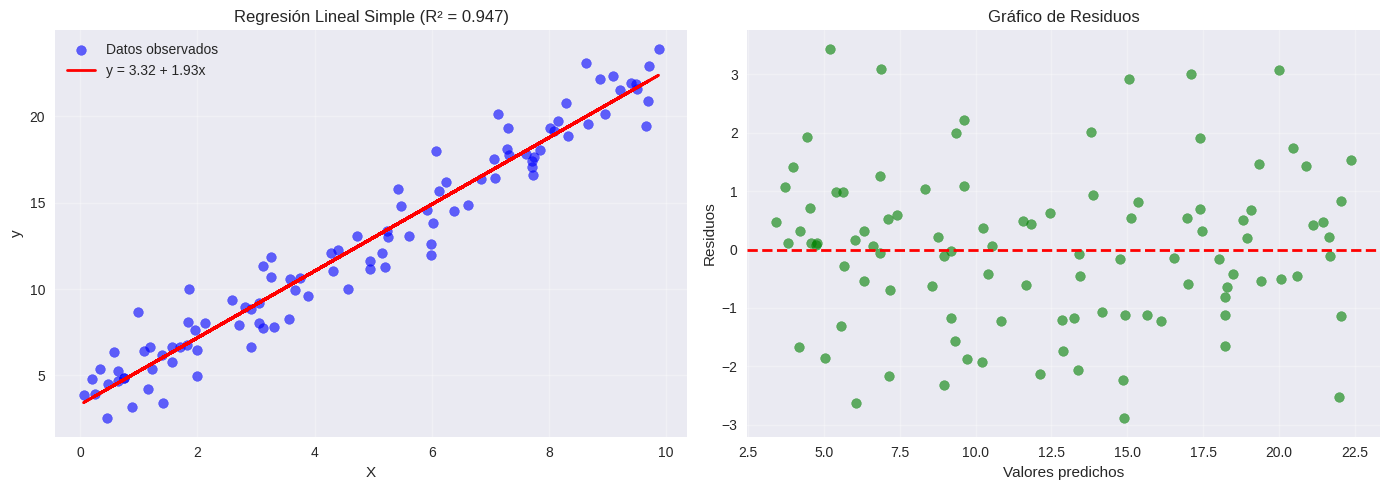

=== Análisis de Residuos ===
✓ Los residuos deben distribuirse aleatoriamente alrededor de 0
✓ No debe haber forma de embudo (heterocedasticidad)
✓ No debe haber curvatura (no linealidad)

Media de residuos: -0.000000
Varianza de residuos: 1.814815


In [12]:
# Visualización del modelo ajustado

plt.figure(figsize=(14, 5))

# Gráfico 1: Datos y recta de regresión
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.6, color='blue', label='Datos observados')
plt.plot(X, y_pred, color='red', linewidth=2, 
         label=f'y = {beta_0:.2f} + {beta_1:.2f}x')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Regresión Lineal Simple (R² = {R2:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Residuos vs Predichos
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuos, alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de residuos
print("=== Análisis de Residuos ===")
print("✓ Los residuos deben distribuirse aleatoriamente alrededor de 0")
print("✓ No debe haber forma de embudo (heterocedasticidad)")
print("✓ No debe haber curvatura (no linealidad)")
residuos_mean = np.mean(residuos)
residuos_mean = residuos_mean[0] if hasattr(residuos_mean, "__len__") else residuos_mean
residuos_var = np.var(residuos)
residuos_var = residuos_var[0] if hasattr(residuos_var, "__len__") else residuos_var
print(f"\nMedia de residuos: {residuos_mean:.6f}")
print(f"Varianza de residuos: {residuos_var:.6f}")

In [13]:
#  Experimenta con diferentes parámetros

print("=== ¡EXPERIMENTA! ===")
print("""
Para experimentar, cambia los parámetros en la Celda 2:

1. Cambia np.random.seed(42) → np.random.seed(123)
2. Cambia n = 100 → n = 50 (o 200, 500)
3. Cambia el ruido: np.random.randn(n, 1) * 1.5 → * 3.0 (o 0.5, 5.0)
4. Cambia la relación: 2 * X + 3 → 1.5 * X + 5

Luego ejecuta TODAS las celdas nuevamente.
""")

print("\n📝 PREGUNTAS PARA RESPONDER:")
print("1. ¿Qué pasa con R² cuando aumentas el ruido?")
print("2. ¿Qué pasa con R² cuando aumentas n?")
print("3. ¿Cómo cambian σ², los errores estándar y los intervalos de confianza con más datos?")
print("4. ¿Qué observas en el gráfico de residuos con mucho ruido?")
print("5. ¿Qué sucede si cambias β₀ y β₁? ¿El modelo los recupera?")
print("6. ¿Cómo afecta el ruido a la varianza de los coeficientes?")

=== ¡EXPERIMENTA! ===

Para experimentar, cambia los parámetros en la Celda 2:

1. Cambia np.random.seed(42) → np.random.seed(123)
2. Cambia n = 100 → n = 50 (o 200, 500)
3. Cambia el ruido: np.random.randn(n, 1) * 1.5 → * 3.0 (o 0.5, 5.0)
4. Cambia la relación: 2 * X + 3 → 1.5 * X + 5

Luego ejecuta TODAS las celdas nuevamente.


📝 PREGUNTAS PARA RESPONDER:
1. ¿Qué pasa con R² cuando aumentas el ruido?
2. ¿Qué pasa con R² cuando aumentas n?
3. ¿Cómo cambian σ², los errores estándar y los intervalos de confianza con más datos?
4. ¿Qué observas en el gráfico de residuos con mucho ruido?
5. ¿Qué sucede si cambias β₀ y β₁? ¿El modelo los recupera?
6. ¿Cómo afecta el ruido a la varianza de los coeficientes?


# Actividad 1a
## Uso de la fómula cerrada
### Se usan los mismos datos sintéticos de la actividad anterior
### con la semilla np.random.seed(42) 


In [14]:
### Usar la solución cerrada usando matrices
# y = 2x + 3 + ε

print("Uso DE LA SOLUCIÓN CERRADA CON MATRICES")

# Datos generados anteriormente
# X es (100, 1), y es (100, 1)

# Paso 1: Construir la matriz de diseño X (con intercepto)
# X_design = [1, X] es una matriz de (100, 2)
X_design = np.c_[np.ones((n, 1)), X]  # np.ones((n,1)) crea columna de unos

print("\n=== PASO 1: Matriz de Diseño ===")
print(f"Dimensiones de X_design: {X_design.shape}")
print(f"Primeras 5 filas de X_design:")
print(X_design[:5])

# Paso 2: Calcular X^T · X
XtX = X_design.T @ X_design

print("\n=== PASO 2: Matriz X^T · X ===")
print(f"Dimensiones de XtX: {XtX.shape}")
print(f"X^T · X =\n{XtX}")

# Paso 3: Calcular X^T · y
Xty = X_design.T @ y

print("\n=== PASO 3: Vector X^T · y ===")
print(f"Dimensiones de Xty: {Xty.shape}")
print(f"X^T · y =\n{Xty}")

# Paso 4: Calcular (X^T · X)^(-1)
XtX_inv = np.linalg.inv(XtX)

print("\n=== PASO 4: Inversa de X^T · X ===")
print(f"(X^T · X)^(-1) =\n{XtX_inv}")

# Paso 5: Calcular β = (X^T · X)^(-1) · X^T · y
beta_mat = XtX_inv @ Xty

print("\n=== PASO 5: Vector de Coeficientes β ===")
print(f"β = (X^T · X)^(-1) · X^T · y")
print(f"β_0 (intersección) = {beta_mat[0,0]:.6f}")
print(f"β_1 (pendiente) = {beta_mat[1,0]:.6f}")
print(f"\nValores reales: β_0 = 3, β_1 = 2")
print(f"Error en β_0: {abs(beta_mat[0,0] - 3):.6f}")
print(f"Error en β_1: {abs(beta_mat[1,0] - 2):.6f}")

Uso DE LA SOLUCIÓN CERRADA CON MATRICES

=== PASO 1: Matriz de Diseño ===
Dimensiones de X_design: (100, 2)
Primeras 5 filas de X_design:
[[1.         3.74540119]
 [1.         9.50714306]
 [1.         7.31993942]
 [1.         5.98658484]
 [1.         1.5601864 ]]

=== PASO 2: Matriz X^T · X ===
Dimensiones de XtX: (2, 2)
X^T · X =
[[ 100.          470.18074338]
 [ 470.18074338 3086.84881613]]

=== PASO 3: Vector X^T · y ===
Dimensiones de Xty: (2, 1)
X^T · y =
[[1240.19943273]
 [7523.053403  ]]

=== PASO 4: Inversa de X^T · X ===
(X^T · X)^(-1) =
[[ 0.03523199 -0.00536644]
 [-0.00536644  0.00114136]]

=== PASO 5: Vector de Coeficientes β ===
β = (X^T · X)^(-1) · X^T · y
β_0 (intersección) = 3.322644
β_1 (pendiente) = 1.931034

Valores reales: β_0 = 3, β_1 = 2
Error en β_0: 0.322644
Error en β_1: 0.068966


In [15]:
# Predicciones usando la solución matricial

print("=" * 60)
print("PREDICCIONES USANDO LA SOLUCIÓN MATRICIAL")
print("=" * 60)

# Predicciones: ŷ = X · β
y_pred_mat = X_design @ beta_mat

print("\n=== Predicciones ===")
print(f"Dimensiones de y_pred: {y_pred_mat.shape}")
print(f"Primeras 10 predicciones vs valores reales:")
print("   y_real   y_pred   residuo")
print("-" * 30)
for i in range(10):
    print(f"{i+1:2d}  {y[i,0]:6.2f}   {y_pred_mat[i,0]:6.2f}   {y[i,0] - y_pred_mat[i,0]:7.3f}")

# Residuos
e = y - y_pred_mat

print("\n=== Estadísticas de Residuos ===")
print(f"Media de residuos: {np.mean(e):.6f}")
print(f"Suma de residuos: {np.sum(e):.6f}")
print(f"Varianza de residuos: {np.var(e):.6f}")

PREDICCIONES USANDO LA SOLUCIÓN MATRICIAL

=== Predicciones ===
Dimensiones de y_pred: (100, 1)
Primeras 10 predicciones vs valores reales:
   y_real   y_pred   residuo
------------------------------
 1   10.62    10.56     0.066
 2   21.57    21.68    -0.115
 3   17.78    17.46     0.320
 4   11.99    14.88    -2.891
 5    5.79     6.34    -0.545
 6    6.66     6.33     0.321
 7    6.38     4.44     1.934
 8   19.55    20.05    -0.503
 9   13.81    14.93    -1.121
10   16.41    17.00    -0.587

=== Estadísticas de Residuos ===
Media de residuos: -0.000000
Suma de residuos: -0.000000
Varianza de residuos: 1.814815


In [ ]:
# Verificación de la demostración de la proyección ortogonal
# X^T · e = 0

print("=" * 60)
print("VER LA DEMOSTRACIÓN DE LA PROYECCIÓN ORTOGONAL")
print("=" * 60)

# Residuos
e = y - y_pred_mat

# Calcular X^T · e
Xt_e = X_design.T @ e

print("\n=== Propiedad clave: X^T · e = 0 ===")
print(f"X^T · e =\n{Xt_e}")
print(f"¿Es aproximadamente cero? {np.allclose(Xt_e, 0, atol=1e-10)}")

# Verificar columna por columna
print(f"\nSuma de residuos (columna de unos): {np.sum(e):.10f}")
print(f"X^T · e (primera columna): {Xt_e[0,0]:.10f}")
print(f"X^T · e (segunda columna): {Xt_e[1,0]:.10f}")

# Verificar que e es ortogonal a cada columna de X
print("\n=== Ortogonalidad con columnas de X ===")
print(f"1^T · e = {np.sum(e):.10f} (debe ser 0)")
print(f"X^T · e = {X.T @ e} (debe ser 0)")

DEMOSTRACIÓN DE LA PROYECCIÓN ORTOGONAL

=== Propiedad clave: X^T · e = 0 ===
X^T · e =
[[-7.09210468e-13]
 [-1.94311234e-12]]
¿Es aproximadamente cero? True

Suma de residuos (columna de unos): -0.0000000000
X^T · e (primera columna): -0.0000000000
X^T · e (segunda columna): -0.0000000000

=== Ortogonalidad con columnas de X ===
1^T · e = -0.0000000000 (debe ser 0)
X^T · e = [[-1.90425453e-12]] (debe ser 0)


In [17]:
# Matriz de proyección H = X·(X^T·X)^(-1)·X^T

print("=" * 60)
print("MATRIZ DE PROYECCIÓN (HAT MATRIX)")
print("=" * 60)

# Calcular la matriz de proyección H
H = X_design @ XtX_inv @ X_design.T

print(f"Dimensiones de H: {H.shape}")
print(f"\nPrimeras 5 filas de H:")
print(H[:5, :5])

# Propiedades de H
print("\n=== Propiedades de la matriz H ===")

# 1. H es simétrica
H_simetrica = np.allclose(H, H.T)
print(f"1. H es simétrica: {H_simetrica}")

# 2. H es idempotente: H² = H
H2 = H @ H
H_idempotente = np.allclose(H, H2)
print(f"2. H es idempotente (H² = H): {H_idempotente}")

# 3. Traza de H = número de parámetros (p = 2)
traza_H = np.trace(H)
print(f"3. Traza(H) = {traza_H:.6f} (debe ser 2)")

# 4. H·y = ŷ
Hy = H @ y
print(f"\n=== Verificación: H·y = ŷ ===")
print(f"Primeros 5 valores de H·y:\n{Hy[:5]}")
print(f"Primeros 5 valores de y_pred:\n{y_pred_mat[:5]}")
print(f"¿Son iguales? {np.allclose(Hy, y_pred_mat, atol=1e-10)}")

MATRIZ DE PROYECCIÓN (HAT MATRIX)
Dimensiones de H: (100, 100)

Primeras 5 filas de H:
[[ 0.01104401  0.00475449  0.00714204  0.00859753  0.0134294 ]
 [ 0.00475449  0.03635538  0.02435942  0.0170465  -0.00723056]
 [ 0.00714204  0.02435942  0.01782357  0.0138392   0.00061213]
 [ 0.00859753  0.0170465   0.0138392   0.01188399  0.00539316]
 [ 0.0134294  -0.00723056  0.00061213  0.00539316  0.02126495]]

=== Propiedades de la matriz H ===
1. H es simétrica: True
2. H es idempotente (H² = H): True
3. Traza(H) = 2.000000 (debe ser 2)

=== Verificación: H·y = ŷ ===
Primeros 5 valores de H·y:
[[10.55514133]
 [21.68126089]
 [17.45769625]
 [14.88294321]
 [ 6.33541725]]
Primeros 5 valores de y_pred:
[[10.55514133]
 [21.68126089]
 [17.45769625]
 [14.88294321]
 [ 6.33541725]]
¿Son iguales? True


In [18]:
# Celda: Descomposición de la varianza usando matrices
# SST = SSR + SSE

print("=" * 60)
print("DESCOMPOSICIÓN DE LA VARIANZA")
print("=" * 60)

# Suma de cuadrados usando matrices
SST = y.T @ y - n * (np.mean(y))**2
SSR = y_pred_mat.T @ y_pred_mat - n * (np.mean(y))**2
SSE = e.T @ e

print("\n=== Suma de Cuadrados ===")
print(f"SST (Total) = {SST[0,0]:.4f}")
print(f"SSR (Explicada) = {SSR[0,0]:.4f}")
print(f"SSE (Residual) = {SSE[0,0]:.4f}")

print(f"\n=== Verificación: SST = SSR + SSE ===")
print(f"SST = {SST[0,0]:.4f}")
print(f"SSR + SSE = {SSR[0,0] + SSE[0,0]:.4f}")
print(f"Diferencia = {SST[0,0] - (SSR[0,0] + SSE[0,0]):.10f}")
print(f"¿Se cumple? {np.allclose(SST, SSR + SSE, atol=1e-10)}")

# R²
R2_mat = SSR / SST
print(f"\nR² = SSR/SST = {R2_mat[0,0]:.4f}")

# Verificar con fórmula alternativa
R2_alt = 1 - SSE/SST
print(f"R² = 1 - SSE/SST = {R2_alt[0,0]:.4f}")

DESCOMPOSICIÓN DE LA VARIANZA

=== Suma de Cuadrados ===
SST (Total) = 3448.5487
SSR (Explicada) = 3267.0672
SSE (Residual) = 181.4815

=== Verificación: SST = SSR + SSE ===
SST = 3448.5487
SSR + SSE = 3448.5487
Diferencia = -0.0000000000
¿Se cumple? True

R² = SSR/SST = 0.9474
R² = 1 - SSE/SST = 0.9474
